# Tutorial Gaussian Process (GP) Regression From Scratch

Dokumen ini dirancang khusus untuk mempelajari **Gaussian Process (GP)** dari dasar (*from scratch*). Setiap bagian penjelasan dilengkapi dengan persamaan matematika dalam format **LaTeX** dan kode **Python** yang dapat dieksekusi secara berurutan.

--- 

## 1. Pengenalan Gaussian Process

Secara intuitif, jika *Distribusi Gaussian* adalah distribusi atas **variabel acak** (skalar atau vektor), maka **Gaussian Process** adalah distribusi atas **fungsi**.

Secara formal, **Gaussian Process** adalah kumpulan variabel acak yang tak terhingga jumlahnya, di mana setiap himpunan bagian berhingga dari variabel acak tersebut memiliki distribusi **Gaussian Bersama (Joint Gaussian Distribution)**.

Sebuah Gaussian Process didefinisikan secara lengkap oleh dua fungsi:
1. **Fungsi Mean $m(x)$**: Ekspetasi dari fungsi pada titik $x$.
   $$m(x) = \mathbb{E}[f(x)]$$
2. **Fungsi Kovarians (Kernel) $k(x, x')$**: Mengukur korelasi/kemiripan antara nilai fungsi pada dua titik $x$ dan $x'$.
   $$k(x, x') = \text{Cov}(f(x), f(x')) = \mathbb{E}[(f(x) - m(x))(f(x') - m(x'))]$$

Secara notasi matematis, kita menuliskan proses ini sebagai:
$$f(x) \sim \mathcal{GP}\left(m(x), k(x, x')\right)$$

Dalam praktiknya, kita sering mengasumsikan mean awal (prior mean) sama dengan nol, yaitu $m(x) = 0$.

In [1]:
# Jika matplotlib/scipy belum terdeteksi oleh kernel Jupyter, hilangkan tanda '#' pada baris berikut untuk menginstal:
# %pip install matplotlib scipy numpy

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# Set random seed agar hasil dapat direproduksi
np.random.seed(42)
print("Library NumPy, Matplotlib, dan SciPy berhasil diimpor!")

Library NumPy, Matplotlib, dan SciPy berhasil diimpor!


## 2. Pembuatan Data Dummy ($N = 200$)

Untuk menguji ketangguhan model GP dan bereksperimen dengan kernel, kita membuat data dummy berukuran $N = 200$ titik observasi.

Fungsi target yang kita pilih bersifat **non-trivial** (menggabungkan sinusoide frekuensi rendah, frekuensi tinggi, dan tren kuadratik):

$$f(x) = \sin(2\pi x) + 0.6 \sin(6\pi x) + 0.3 x^2$$

Observasi yang kita terima memiliki derau (*noise*) Gaussian independen $\epsilon_i \sim \mathcal{N}(0, \sigma_n^2)$:

$$y_i = f(x_i) + \epsilon_i, \quad \sigma_n = 0.15$$

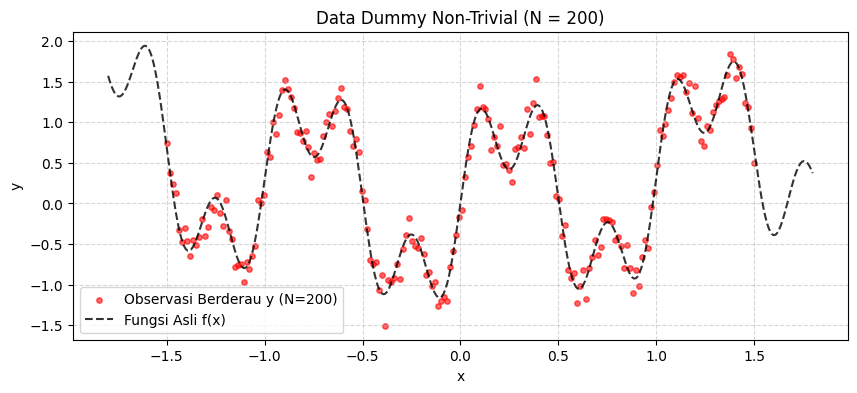

In [2]:
def target_function(x):
    """Fungsi target non-trivial yang menggabungkan berbagai frekuensi dan tren."""
    return np.sin(2 * np.pi * x) + 0.6 * np.sin(6 * np.pi * x) + 0.3 * (x ** 2)

def generate_data(n_samples=200, noise_std=0.15):
    """Menghasilkan N data dummy berderau dalam rentang [-1.5, 1.5]."""
    X = np.linspace(-1.5, 1.5, n_samples).reshape(-1, 1)
    y_true = target_function(X).ravel()
    y_noisy = y_true + np.random.normal(0, noise_std, size=n_samples)
    return X, y_noisy, y_true

# Generasi data dummy N = 200
X_train, y_train, y_true = generate_data(n_samples=200, noise_std=0.15)
X_test = np.linspace(-1.8, 1.8, 400).reshape(-1, 1)
y_test_true = target_function(X_test).ravel()

# Visualisasi Data Training
plt.figure(figsize=(10, 4))
plt.scatter(X_train, y_train, color='red', s=15, alpha=0.6, label='Observasi Berderau y (N=200)')
plt.plot(X_test, y_test_true, 'k--', label='Fungsi Asli f(x)', alpha=0.8)
plt.title("Data Dummy Non-Trivial (N = 200)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## 3. Fungsi Kovarians (Kernel) From Scratch

Kernel menentukan asumsi kehalusan (*smoothness*), periodisitas, dan struktur dari fungsi yang ingin difit.

### A. Radial Basis Function (RBF / Squared Exponential) Kernel
Kernel RBF adalah kernel yang paling populer untuk fungsi yang sangat halus (*infinitely differentiable*):
$$k_{\text{RBF}}(x, x') = \sigma_f^2 \exp\left( - \frac{(x - x')^2}{2 l^2} \right)$$
di mana:
- $\sigma_f^2$ adalah varians output (*output scale*).
- $l$ adalah skala panjang (*length-scale*) yang menentukan seberapa cepat korelasi meluruh seiring bertambahnya jarak.

### B. Periodic Kernel
Digunakan untuk memodelkan pola berulang/periodik:
$$k_{\text{periodic}}(x, x') = \sigma_f^2 \exp\left( - \frac{2 \sin^2\left( \frac{\pi |x - x'|}{p} \right)}{l^2} \right)$$
di mana $p$ adalah periode gelombang.

### C. Matérn 3/2 Kernel
Kernel Matérn memberikan asumsi fungsi yang kurang halus dibandingkan RBF, sangat cocok untuk data dunia nyata yang memiliki variasi lokal tajam:
$$k_{\text{Matérn3/2}}(x, x') = \sigma_f^2 \left(1 + \frac{\sqrt{3}|x - x'|}{l}\right) \exp\left( - \frac{\sqrt{3}|x - x'|}{l} \right)$$

### D. Operasi Aritmatika Kernel (Komposisi Kernel)
Kita dapat menggabungkan dua kernel $k_1$ dan $k_2$ melalui penjumlah atau perkalian:
- **Penjumlahan Kernel**: $(k_1 + k_2)(x, x') = k_1(x, x') + k_2(x, x')$
- **Perkalian Kernel**: $(k_1 \times k_2)(x, x') = k_1(x, x') \cdot k_2(x, x')$

In [3]:
class Kernel:
    """Base Class Kernel yang mendukung operasi penjumlahan dan perkalian."""
    def __call__(self, X1, X2):
        raise NotImplementedError
    
    def __add__(self, other):
        return SumKernel(self, other)
    
    def __mul__(self, other):
        return ProductKernel(self, other)

class RBFKernel(Kernel):
    def __init__(self, length_scale=1.0, variance=1.0):
        self.length_scale = length_scale
        self.variance = variance
        
    def __call__(self, X1, X2):
        # Matriks jarak kuadrat: dist_sq[i, j] = (X1[i] - X2[j])^2
        dist_sq = np.sum(X1**2, axis=1, keepdims=True) + np.sum(X2**2, axis=1) - 2 * np.dot(X1, X2.T)
        dist_sq = np.maximum(dist_sq, 0.0)
        return self.variance * np.exp(-0.5 * dist_sq / (self.length_scale ** 2))

class PeriodicKernel(Kernel):
    def __init__(self, length_scale=1.0, period=1.0, variance=1.0):
        self.length_scale = length_scale
        self.period = period
        self.variance = variance
        
    def __call__(self, X1, X2):
        abs_diff = np.abs(X1 - X2.T)
        sin_comp = np.sin(np.pi * abs_diff / self.period)
        return self.variance * np.exp(-2.0 * (sin_comp ** 2) / (self.length_scale ** 2))

class Matern32Kernel(Kernel):
    def __init__(self, length_scale=1.0, variance=1.0):
        self.length_scale = length_scale
        self.variance = variance
        
    def __call__(self, X1, X2):
        dist_sq = np.sum(X1**2, axis=1, keepdims=True) + np.sum(X2**2, axis=1) - 2 * np.dot(X1, X2.T)
        r = np.sqrt(np.maximum(dist_sq, 1e-12))
        sqrt3_r_l = np.sqrt(3.0) * r / self.length_scale
        return self.variance * (1.0 + sqrt3_r_l) * np.exp(-sqrt3_r_l)

class SumKernel(Kernel):
    def __init__(self, k1, k2):
        self.k1 = k1
        self.k2 = k2
        
    def __call__(self, X1, X2):
        return self.k1(X1, X2) + self.k2(X1, X2)

class ProductKernel(Kernel):
    def __init__(self, k1, k2):
        self.k1 = k1
        self.k2 = k2
        
    def __call__(self, X1, X2):
        return self.k1(X1, X2) * self.k2(X1, X2)

print("Modul Kernel dari awal berhasil dibuat!")

Modul Kernel dari awal berhasil dibuat!


## 4. Sampling Fungsi dari Prior GP

Sebelum melihat data observasi, prior GP mendefinisikan distribusi atas fungsi:

$$\mathbf{f}_* \sim \mathcal{N}\left(\mathbf{0}, \mathbf{K}(\mathbf{X}_*, \mathbf{X}_*)\right)$$

Untuk mengambil sampel acak fungsi $\mathbf{f}_*$ dari prior ini, kita menggunakan **Dekomposisi Cholesky**:
1. Hitung matriks kovarians $\mathbf{K}_{**} = k(\mathbf{X}_*, \mathbf{X}_*) + \epsilon \mathbf{I}$.
2. Cari matriks segitiga bawah $\mathbf{L}_{**}$ sedemikian hingga $\mathbf{L}_{**} \mathbf{L}_{**}^T = \mathbf{K}_{**}$.
3. Ambil sampel acak standar $\mathbf{u} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$.
4. Sampel fungsi diperoleh melalui perkalian matriks:
   $$\mathbf{f}_{\text{prior}} = \mathbf{L}_{**} \mathbf{u}$$


$$\mathbf{u} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$$
$(\mathbf{L})$
$$\mathbf{L} \mathbf{L}^T = \mathbf{K}{**}$$

Jika kita mendefinisikan sampel fungsi $\mathbf{f} = \mathbf{L} \mathbf{u}$, mari kita hitung Matriks Kovarians dari $\mathbf{f}$:

$$\text{Cov}(\mathbf{f}) = \mathbb{E}[\mathbf{f} \mathbf{f}^T]$$ $$\text{Cov}(\mathbf{f}) = \mathbb{E}[(\mathbf{L} \mathbf{u}) (\mathbf{L} \mathbf{u})^T]$$ $$\text{Cov}(\mathbf{f}) = \mathbb{E}[\mathbf{L} \mathbf{u} \mathbf{u}^T \mathbf{L}^T]$$

Karena $\mathbf{L}$ adalah matriks konstanta, kita bisa mengeluarkannya dari ekspetasi: $$\text{Cov}(\mathbf{f}) = \mathbf{L} \cdot \mathbb{E}[\mathbf{u} \mathbf{u}^T] \cdot \mathbf{L}^T$$

Karena $\mathbf{u}$ berasal dari Normal Standar $\mathcal{N}(\mathbf{0}, \mathbf{I})$, nilai $\mathbb{E}[\mathbf{u} \mathbf{u}^T] = \mathbf{I}$: $$\text{Cov}(\mathbf{f}) = \mathbf{L} \cdot \mathbf{I} \cdot \mathbf{L}^T$$ $$\text{Cov}(\mathbf{f}) = \mathbf{L} \mathbf{L}^T = \mathbf{K}_{**}$$

HASILNYA PERSIS SAMA! Perkalian matriks $\mathbf{L} \mathbf{u}$ otomatis mengubah acakan independen $\mathbf{u}$ menjadi sampel fungsi yang memiliki korelasi/kovarians persis sesuai dengan matriks kovarians kernel $\mathbf{K}_{**}$.

1. Definisi Umum Kovarians untuk 1-Dimensi (Skalar)
Di statistik dasar, varians/kovarians dari variabel acak $X$ dengan mean $\mu = \mathbb{E}[X]$ didefinisikan sebagai:

$$\text{Var}(X) = \mathbb{E}[(X - \mu)^2] = \mathbb{E}[(X - \mu)(X - \mu)]$$

2. Definisi Umum Kovarians untuk Banyak Dimensi (Vektor)
Jika kita memiliki vektor acak $\mathbf{f}$ berukuran $N \times 1$:

$$\mathbf{f} = \begin{bmatrix} f_1 \ f_2 \ \vdots \ f_N \end{bmatrix}$$

dan mean-nya adalah vektor $\boldsymbol{\mu} = \mathbb{E}[\mathbf{f}]$, maka Matriks Kovarians $\text{Cov}(\mathbf{f})$ didefinisikan secara formal sebagai:

$$\text{Cov}(\mathbf{f}) = \mathbb{E}\left[ (\mathbf{f} - \boldsymbol{\mu}) (\mathbf{f} - \boldsymbol{\mu})^T \right]$$


3. Mengapa Bisa Menjadi $\mathbb{E}[\mathbf{f} \mathbf{f}^T]$?
Di dalam Gaussian Process Prior, kita selalu mengasumsikan mean-nya adalah nol (Zero-Mean Prior):

$$\boldsymbol{\mu} = \mathbb{E}[\mathbf{f}] = \mathbf{0}$$

Sekarang, mari kita masukkan $\boldsymbol{\mu} = \mathbf{0}$ ke dalam definisi umum di atas:

$$\text{Cov}(\mathbf{f}) = \mathbb{E}\left[ (\mathbf{f} - \mathbf{0}) (\mathbf{f} - \mathbf{0})^T \right]$$ $$\text{Cov}(\mathbf{f}) = \mathbb{E}\left[ \mathbf{f} \mathbf{f}^T \right]$$

Sederhana sekali, bukan? Persamaan menjadi $\mathbb{E}[\mathbf{f} \mathbf{f}^T]$ khusus karena rata-ratanya ($\boldsymbol{\mu}$) bernilai nol.

4. Mari Kita Lihat Isi Matriks $\mathbf{f} \mathbf{f}^T$ Secara Visual
Untuk lebih membayangkan fisik matriksnya, misalkan vektor $\mathbf{f}$ hanya memiliki 2 elemen ($N=2$):

$$\mathbf{f} = \begin{bmatrix} f_1 \ f_2 \end{bmatrix}$$

Transpose dari $\mathbf{f}$ adalah vektor baris $\mathbf{f}^T = \begin{bmatrix} f_1 & f_2 \end{bmatrix}$.

Sekarang lakukan perkalian matriks $\mathbf{f} \mathbf{f}^T$:

$$\mathbf{f} \mathbf{f}^T = \begin{bmatrix} f_1 \ f_2 \end{bmatrix} \begin{bmatrix} f_1 & f_2 \end{bmatrix} = \begin{bmatrix} f_1 \cdot f_1 & f_1 \cdot f_2 \ f_2 \cdot f_1 & f_2 \cdot f_2 \end{bmatrix} = \begin{bmatrix} f_1^2 & f_1 f_2 \ f_2 f_1 & f_2^2 \end{bmatrix}$$

Ketika kita mengambil nilai Ekspektasi ($\mathbb{E}$):

$$\mathbb{E}[\mathbf{f} \mathbf{f}^T] = \begin{bmatrix} \mathbb{E}[f_1^2] & \mathbb{E}[f_1 f_2] \ \mathbb{E}[f_2 f_1] & \mathbb{E}[f_2^2] \end{bmatrix} = \begin{bmatrix} \text{Var}(f_1) & \text{Cov}(f_1, f_2) \ \text{Cov}(f_2, f_1) & \text{Var}(f_2) \end{bmatrix}$$

Diagonal Utama ($\mathbb{E}[f_1^2], \mathbb{E}[f_2^2]$): Berisi Varians dari masing-masing titik.
Di Luar Diagonal ($\mathbb{E}[f_1 f_2]$): Berisi Kovarians (Hubungan/Kemiripan) antara titik $f_1$ dan $f_2$.


1. Mengapa Matriks $\mathbf{L}$ Disebut KONSTAN (Deterministik)?
Matriks $\mathbf{L}$ diperoleh dari Dekomposisi Cholesky atas Matriks Kovarians Kernel $\mathbf{K}_{**}$:

$$\mathbf{L} \mathbf{L}^T = \mathbf{K}(\mathbf{X}*, \mathbf{X}*)$$

Mari kita lihat dari mana $\mathbf{K}_{**}$ berasal:

Titik uji $\mathbf{X}_*$ adalah titik-titik lokasi koordinat yang kita tentukan sendiri (misal 400 titik dari -1.8 sampai 1.8).
Rumus Kernel RBF $k(x, x') = \sigma_f^2 \exp\left( -\frac{(x - x')^2}{2 l^2} \right)$ adalah rumus pasti.
Karena lokasi $\mathbf{X}_*$ pasti dan rumus kernelnya pasti, maka isi angka di dalam matriks $\mathbf{L}$ nilainya 100% pasti dan tidak pernah berubah-ubah (tidak mengandung keacakan).

Kesimpulan: $\mathbf{L}$ adalah Matriks Konstan / Tetap.

2. Mengapa $\mathbf{u}$ Disebut VARIABEL ACAK (Random Vector)?
Matriks/vektor $\mathbf{u}$ dibuat menggunakan fungsi pembuat angka acak komputasi:

python
u = np.random.normal(0, 1, size=(400, 5))
Setiap kali Anda mengeksekusi kode di atas (atau melempar dadu), isi angka di dalam $\mathbf{u}$ akan selalu berubah-ubah secara acak.
Karena nilainya tidak pasti dan berubah-ubah mengikuti distribusi Gauss $\mathcal{N}(\mathbf{0}, \mathbf{I})$, maka $\mathbf{u}$ adalah Variabel Acak (Random Vector).

3. Sifat Operator Ekspektasi $\mathbb{E}[\dots]$ terhadap Konstan
Operator Ekspektasi $\mathbb{E}[\dots]$ pada dasarnya adalah "Rata-rata dari nilai-nilai acak".

Di statistik dasar (1-Dimensi), jika $c$ adalah angka konstan dan $X$ adalah variabel acak, maka: $$\mathbb{E}[c \cdot X] = c \cdot \mathbb{E}[X]$$ (Angka konstan $c$ tidak ikut dirata-ratakan, sehingga bisa dikeluarkan dari tanda $\mathbb{E}$).

Hal yang sama berlaku pada Aljabar Matriks! Karena $\mathbf{L}$ adalah matriks konstan (bukan variabel acak), $\mathbf{L}$ bisa ditarik keluar dari operator ekspektasi $\mathbb{E}[\dots]$:

$$\mathbb{E}\left[ \mathbf{L} \cdot (\mathbf{u} \mathbf{u}^T) \cdot \mathbf{L}^T \right] = \mathbf{L} \cdot \mathbb{E}[\mathbf{u} \mathbf{u}^T] \cdot \mathbf{L}^T$$

Hanya komponen $(\mathbf{u} \mathbf{u}^T)$ di tengah yang perlu dirata-ratakan oleh operator $\mathbb{E}[\dots]$ karena hanya $\mathbf{u}$ yang bersifat acak!

Pernyataan $\mathbf{u} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ berarti bahwa vektor $\mathbf{u}$ berisi angka-angka acak yang independen satu sama lain, di mana masing-masing angka berasal dari Distribusi Normal Standar $\mathcal{N}(0, 1)$.

Dari definisi Distribusi Normal Standar 1-Dimensi $u_i \sim \mathcal{N}(0, 1)$, kita memiliki 3 fakta kunci:

Mean-nya = 0: $\mathbb{E}[u_i] = 0$
Varians-nya = 1: $$\text{Var}(u_i) = \mathbb{E}[u_i^2] - (\mathbb{E}[u_i])^2 = \mathbb{E}[u_i^2] - 0^2 = \mathbf{1} \implies \mathbb{E}[u_i^2] = 1$$
Independen (Tidak Berkorelasi): Karena $u_i$ dan $u_j$ ($i \neq j$) ditarik secara terpisah/independen: $$\mathbb{E}[u_i \cdot u_j] = \mathbb{E}[u_i] \cdot \mathbb{E}[u_j] = 0 \cdot 0 = \mathbf{0}$$
Mari Kita Lihat Isi Matriks $\mathbf{u} \mathbf{u}^T$
Misalkan vektor $\mathbf{u}$ berisi 3 elemen: $\mathbf{u} = \begin{bmatrix} u_1 \ u_2 \ u_3 \end{bmatrix}$.

Perkalian matriks $\mathbf{u} \mathbf{u}^T$ adalah:

$$\mathbf{u} \mathbf{u}^T = \begin{bmatrix} u_1 \ u_2 \ u_3 \end{bmatrix} \begin{bmatrix} u_1 & u_2 & u_3 \end{bmatrix} = \begin{bmatrix} u_1^2 & u_1 u_2 & u_1 u_3 \ u_2 u_1 & u_2^2 & u_2 u_3 \ u_3 u_1 & u_3 u_2 & u_3^2 \end{bmatrix}$$

Sekarang Ambil Nilai Ekspektasi $\mathbb{E}[\mathbf{u} \mathbf{u}^T]$
Kita terapkan nilai ekspektasi ke setiap elemen di dalam matriks:

$$\mathbb{E}[\mathbf{u} \mathbf{u}^T] = \begin{bmatrix} \mathbb{E}[u_1^2] & \mathbb{E}[u_1 u_2] & \mathbb{E}[u_1 u_3] \ \mathbb{E}[u_2 u_1] & \mathbb{E}[u_2^2] & \mathbb{E}[u_2 u_3] \ \mathbb{E}[u_3 u_1] & \mathbb{E}[u_3 u_2] & \mathbb{E}[u_3^2] \end{bmatrix}$$

Masukkan 3 fakta kunci dari atas tadi:

Pada Diagonal Utama (di mana elemennya sama, $i = j$):
$$\mathbb{E}[u_1^2] = 1, \quad \mathbb{E}[u_2^2] = 1, \quad \mathbb{E}[u_3^2] = 1$$

Di Luar Diagonal (di mana elemennya berbeda, $i \neq j$):
$$\mathbb{E}[u_1 u_2] = 0, \quad \mathbb{E}[u_1 u_3] = 0, \quad \mathbb{E}[u_2 u_3] = 0$$

Hasil Akhir
Substitusikan angka-angka tersebut ke dalam matriks:

$$\mathbb{E}[\mathbf{u} \mathbf{u}^T] = \begin{bmatrix} \mathbf{1} & \mathbf{0} & \mathbf{0} \ \mathbf{0} & \mathbf{1} & \mathbf{0} \ \mathbf{0} & \mathbf{0} & \mathbf{1} \end{bmatrix} = \mathbf{I}$$

SELESAI!
Itulah alasannya mengapa $\mathbb{E}[\mathbf{u} \mathbf{u}^T]$ bernilai Matriks Identitas ($\mathbf{I}$):

Angka 1 pada diagonal utama mewakili varians masing-masing elemen yang bernilai 1.
Angka 0 di luar diagonal mewakili bahwa elemen-elemennya bersifat independen (kovarians = 0).

Secara umum, notasi distribusi normal banyak dimensi ditulis sebagai:

$$\mathbf{u} \sim \mathcal{N}(\boldsymbol{\mu}, \boldsymbol{\Sigma})$$

$\boldsymbol{\mu}$: Adalah Vektor Rata-Rata (Mean).
$\boldsymbol{\Sigma}$: Adalah Matriks Kovarians, yaitu matriks yang menyimpan nilai varians dan korelasi antar variabel.
Ketika kita menulis $\mathbf{u} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$, artinya kita menetapkan Matriks Kovarians $\boldsymbol{\Sigma} = \mathbf{I}$ (Matriks Identitas).

1. Struktur Matriks Identitas $\mathbf{I}$
Mari kita lihat isi bentuk dari Matriks Identitas $\mathbf{I}$:

$$\mathbf{I} = \begin{bmatrix} \mathbf{1} & 0 & 0 \ 0 & \mathbf{1} & 0 \ 0 & 0 & \mathbf{1} \end{bmatrix}$$

Aturan membaca Matriks Kovarians $\boldsymbol{\Sigma}$:

Angka pada Diagonal Utama (bernilai 1): Menunjukkan Varians dari masing-masing variabel $u_i$. Artinya $\text{Var}(u_1) = 1, \text{Var}(u_2) = 1$, dst.
Angka di Luar Diagonal (bernilai 0): Menunjukkan Kovarians / Korelasi antara variabel ke-$i$ dan ke-$j$. Artinya $\text{Cov}(u_1, u_2) = 0, \text{Cov}(u_1, u_3) = 0$, dst.
2. HubunganAntara Kovarians = 0 dan Independensi
Dalam ilmu statistik:

Jika $\text{Cov}(u_i, u_j) = 0$, artinya tidak ada hubungan linear/korelasi sama sekali antara angka $u_i$ dan angka $u_j$.
Khusus untuk Distribusi Gaussian (Normal), terdapat sifat keistimewaan khusus: Jika Kovarians-nya $0$, maka variabel-variabel tersebut dijamin pasti INDEPENDEN (bebas murni satu sama lain)!
3. Bukti dari Fungsi Peluang (PDF)
Dalam teori peluang, dua variabel $A$ dan $B$ dikatakan independen jika peluang gabungannya adalah hasil kali peluang masing-masing:

$$p(A, B) = p(A) \cdot p(B)$$

Ketika matriks kovariansnya adalah $\mathbf{I}$, rumus peluang Multivariate Gaussian $p(\mathbf{u})$ yang rumit dapat dipecah secara matematis menjadi:

$$p(u_1, u_2, \dots, u_N) = p(u_1) \cdot p(u_2) \cdots p(u_N)$$

di mana masing-masing $p(u_i)$ adalah Distribusi Normal Standar $\mathcal{N}(0, 1)$ biasa!

Ringkasan
Notasi $\mathbf{I}$ pada $\mathcal{N}(\mathbf{0}, \mathbf{I})$ membuat seluruh nilai kovarians di luar diagonal bernilai 0.
Kovarians 0 pada distribusi Gaussian berarti angka-angka di dalam vektor $\mathbf{u}$ ditarik secara acak dan independen, tanpa saling mempengaruhi satu sama lain.

Mari kita buktikan secara matematis menggunakan sifat linieritas dari nilai Ekspektasi ($\mathbb{E}[\dots]$):

Bukti Matematis
Kita tahu bahwa $\mathbf{u}$ ditarik dari Normal Standar $\mathcal{N}(\mathbf{0}, \mathbf{I})$, sehingga mean dari $\mathbf{u}$ adalah: $$\mathbb{E}[\mathbf{u}] = \mathbf{0}$$

Sekarang mari kita hitung mean dari $\mathbf{f} = \mathbf{L} \mathbf{u}$: $$\mathbb{E}[\mathbf{f}] = \mathbb{E}[\mathbf{L} \mathbf{u}]$$

Karena $\mathbf{L}$ adalah matriks konstan (tidak acak), $\mathbf{L}$ bisa dikeluarkan dari operator ekspektasi: $$\mathbb{E}[\mathbf{f}] = \mathbf{L} \cdot \mathbb{E}[\mathbf{u}]$$

Masukkan nilai $\mathbb{E}[\mathbf{u}] = \mathbf{0}$: $$\mathbb{E}[\mathbf{f}] = \mathbf{L} \cdot \mathbf{0} = \mathbf{0}$$

Kesimpulan: Mean dari $\mathbf{f}$ adalah $\mathbf{0}$, sama persis dengan mean dari $\mathbf{u}$!

Bagaimana Jika Kita Ingin GP Prior dengan Mean Tidak Nol ($\mathbf{m}$)?
Dalam praktiknya, jika suatu hari Anda ingin sampel fungsi $\mathbf{f}$ memiliki mean tertentu $\mathbf{m} = m(\mathbf{X}_*)$ (misalnya $\mathbf{m} = 5$ atau $\mathbf{m} = 2x$), Anda cukup menambahkan $\mathbf{m}$ ke dalam persamaan:

$$\mathbf{f} = \mathbf{m} + \mathbf{L} \mathbf{u}$$

Mari kita cek mean-nya sekarang: $$\mathbb{E}[\mathbf{f}] = \mathbb{E}[\mathbf{m} + \mathbf{L} \mathbf{u}] = \mathbf{m} + \mathbf{L} \cdot \mathbb{E}[\mathbf{u}] = \mathbf{m} + \mathbf{0} = \mathbf{m}$$

Mean-nya menjadi $\mathbf{m}$.
Matriks Kovarians-nya tetap sama yaitu $\mathbf{K}_{**} = \mathbf{L} \mathbf{L}^T$ (karena penambahan angka konstan $\mathbf{m}$ tidak menggeser/mengubah varians).

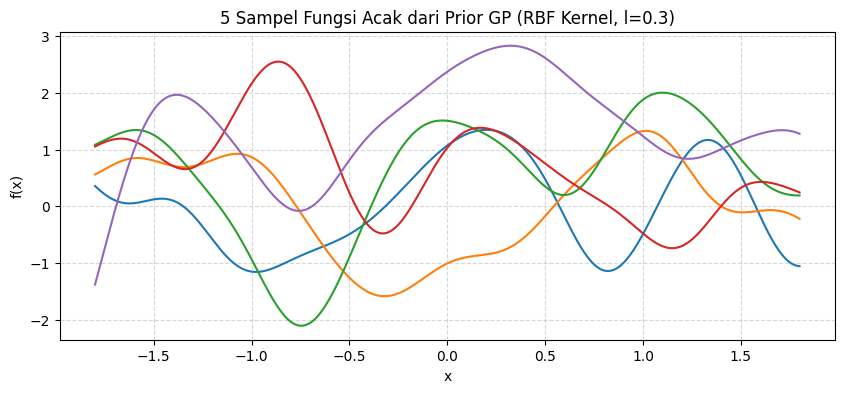

In [4]:
# Contoh Sampling dari Prior RBF Kernel
rbf = RBFKernel(length_scale=0.3, variance=1.0)
K_ss = rbf(X_test, X_test) + 1e-8 * np.eye(len(X_test))
L_ss = np.linalg.cholesky(K_ss)
u = np.random.normal(0, 1, size=(len(X_test), 5))
prior_samples = np.dot(L_ss, u)

plt.figure(figsize=(10, 4))
plt.plot(X_test, prior_samples)
plt.title("5 Sampel Fungsi Acak dari Prior GP (RBF Kernel, l=0.3)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## 5. Formulasi Matematika GP Regression & Posterior Conditioning

Ketika kita memiliki data training berderau $\mathbf{y} = [y_1, y_2, \dots, y_N]^T$ pada titik $\mathbf{X}$, dan ingin memprediksi nilai fungsi $\mathbf{f}_*$ pada titik pengujian baru $\mathbf{X}_*$, kita membentuk **Distribusi Gaussian Bersama (Joint Distribution)**:

$$\begin{bmatrix} \mathbf{y} \\ \mathbf{f}_* \end{bmatrix} \sim \mathcal{N}\left( \begin{bmatrix} \mathbf{0} \\ \mathbf{0} \end{bmatrix}, \begin{bmatrix} \mathbf{K}_y & \mathbf{K}_* \\ \mathbf{K}_*^T & \mathbf{K}_{**} \end{bmatrix} \right)$$



di mana:
- $\mathbf{K}_y = \mathbf{K}(\mathbf{X}, \mathbf{X}) + \sigma_n^2 \mathbf{I}_N$ (Matriks kovarians data observasi berderau).
- $\mathbf{K}_* = \mathbf{K}(\mathbf{X}, \mathbf{X}_*)$ (Matriks kovarians antara data training dan data pengujian).
- $\mathbf{K}_{**} = \mathbf{K}(\mathbf{X}_*, \mathbf{X}_*)$ (Matriks kovarians antar data pengujian).

Dengan menerapkan **Teorema Kondisioning Gaussian**, distribusi posterior $p(\mathbf{f}_* \mid \mathbf{X}, \mathbf{y}, \mathbf{X}_*) = \mathcal{N}(\boldsymbol{\mu}_*, \boldsymbol{\Sigma}_*)$ memiliki mean dan matriks kovarians sebagai berikut:

1. **Posterior Mean**:
   $$\boldsymbol{\mu}_* = \mathbf{K}_*^T \mathbf{K}_y^{-1} \mathbf{y}$$
2. **Posterior Covariance**:
   $$\boldsymbol{\Sigma}_* = \mathbf{K}_{**} - \mathbf{K}_*^T \mathbf{K}_y^{-1} \mathbf{K}_*$$

---

### Stabilitas Numerik dengan Dekomposisi Cholesky
Menghitung invers matriks $\mathbf{K}_y^{-1}$ secara langsung berisiko tinggi menyebabkan ketidakstabilan numerik (*ill-conditioned matrix*). Oleh karena itu, kita selalu menggunakan **Dekomposisi Cholesky**:

$$\mathbf{L} \mathbf{L}^T = \mathbf{K}_y$$

di mana $\mathbf{L}$ adalah matriks segitiga bawah. Perhitungan posterior kemudian diubah menjadi:
1. Hitung $\boldsymbol{\alpha} = \mathbf{L}^T \backslash (\mathbf{L} \backslash \mathbf{y})$, sehingga $\boldsymbol{\mu}_* = \mathbf{K}_*^T \boldsymbol{\alpha}$.
2. Hitung $\mathbf{v} = \mathbf{L} \backslash \mathbf{K}_*$.
3. Matriks Kovarians Posterior: $\boldsymbol{\Sigma}_* = \mathbf{K}_{**} - \mathbf{v}^T \mathbf{v}$.
4. Varians Posterior untuk setiap titik pengujian: $\sigma_*^2 = \text{diag}(\boldsymbol{\Sigma}_*)$.

---

### Log Marginal Likelihood (Fungsi Objektif Optimasi)
Untuk mengukur seberapa cocok hyperparameter kernel $\boldsymbol{\theta}$ terhadap data training, kita menggunakan **Log Marginal Likelihood**:

$$\log p(\mathbf{y} \mid \mathbf{X}, \boldsymbol{\theta}) = -\frac{1}{2} \mathbf{y}^T \mathbf{K}_y^{-1} \mathbf{y} - \frac{1}{2} \log |\mathbf{K}_y| - \frac{N}{2} \log(2\pi)$$

Menggunakan matriks Cholesky $\mathbf{L}$, persamaan di atas dapat dihitung dengan efisien:

$$\log p(\mathbf{y} \mid \mathbf{X}, \boldsymbol{\theta}) = -\frac{1}{2} \mathbf{y}^T \boldsymbol{\alpha} - \sum_{i=1}^N \log L_{ii} - \frac{N}{2} \log(2\pi)$$

1. Intuisi Utama: Mengapa Perlu Joint Distribution & Conditioning?
Dalam Gaussian Process (GP):

Sebelum melihat data observasi, kita mengasumsikan vektor nilai fungsi $\mathbf{f}{\ast}$ di titik uji $\mathbf{X}{\ast}$ mengikuti distribusi GP Prior: $\mathbf{f}{\ast} \sim \mathcal{N}(\mathbf{0}, \mathbf{K}{\ast \ast})$.
Begitu kita melihat vektor observasi berderau $\mathbf{y}$ pada lokasi matriks data training $\mathbf{X}$, data tersebut memberikan informasi tentang bentuk fungsi pada lokasi matriks titik uji baru $\mathbf{X}_{\ast}$.
Kondisioning (Conditioning) adalah proses statistik untuk menentukan distribusi bersyarat (posterior) $p(\mathbf{f}{\ast} \mid \mathbf{X}, \mathbf{y}, \mathbf{X}{\ast})$:
"Jika kita mengamati vektor data training $\mathbf{y}$, bagaimana distribusi probabilitas posterior vektor target $\mathbf{f}{\ast}$ pada matriks titik uji baru $\mathbf{X}{\ast}$?"

2. Matriks Kovarians Bersama (Joint Distribution Matrix)
Ketika kita memiliki data training berderau $\mathbf{y} = [y_1, y_2, \dots, y_N]^T$ pada titik $\mathbf{X}$, dan ingin memprediksi nilai fungsi $\mathbf{f}{\ast}$ pada titik pengujian baru $\mathbf{X}{\ast}$, kita membentuk Distribusi Gaussian Bersama (Joint Distribution):

$$ \begin{bmatrix} \mathbf{y} \\ \mathbf{f}{\ast} \end{bmatrix} \sim \mathcal{N}\left( \begin{bmatrix} \mathbf{0} \\ \mathbf{0} \end{bmatrix}, \begin{bmatrix} \mathbf{K}y & \mathbf{K}{\ast} \\ \mathbf{K}{\ast}^T & \mathbf{K}_{\ast \ast} \end{bmatrix} \right) $$

Dimensi dan makna tiap elemen matriks kovarians blok:

$\mathbf{y} = [y_1, y_2, \dots, y_N]^T \in \mathbb{R}^{N \times 1}$ : Vektor observasi berderau $y_i = f(x_i) + \epsilon_i$.
$\mathbf{f}{\ast} \in \mathbb{R}^{N{\ast} \times 1}$ : Vektor nilai prediksi fungsi pada lokasi pengujian baru $\mathbf{X}_{\ast}$.
$\mathbf{K}_y = \mathbf{K}(\mathbf{X}, \mathbf{X}) + \sigma_n^2 \mathbf{I}_N \in \mathbb{R}^{N \times N}$ : Matriks kovarians data observasi berderau.
$\mathbf{K}{\ast} = \mathbf{K}(\mathbf{X}, \mathbf{X}{\ast}) \in \mathbb{R}^{N \times N_{\ast}}$ : Matriks kovarians silang (cross-covariance matrix) antara titik training $\mathbf{X}$ dan titik uji $\mathbf{X}_{\ast}$.
$\mathbf{K}{\ast \ast} = \mathbf{K}(\mathbf{X}{\ast}, \mathbf{X}{\ast}) \in \mathbb{R}^{N{\ast} \times N_{\ast}}$ : Matriks kovarians antar titik uji baru $\mathbf{X}_{\ast}$.

3. Teorema Kondisioning Gaussian (Posterior Formula)
Dengan menerapkan Teorema Kondisioning Gaussian, distribusi posterior $p(\mathbf{f}{\ast} \mid \mathbf{X}, \mathbf{y}, \mathbf{X}{\ast}) = \mathcal{N}(\boldsymbol{\mu}{\ast}, \boldsymbol{\Sigma}{\ast})$ menghasilkan vektor mean posterior dan matriks kovarians posterior:

A. Vektor Posterior Mean ($\boldsymbol{\mu}{\ast} \in \mathbb{R}^{N{\ast} \times 1}$)
$$ \boldsymbol{\mu}{\ast} = \mathbf{K}{\ast}^T \mathbf{K}_y^{-1} \mathbf{y} $$

Vektor mean posterior $\boldsymbol{\mu}_{\ast}$ merupakan kombinasi linier dari vektor observasi $\mathbf{y}$.
Jika kita definisikan vektor bobot $\boldsymbol{\alpha} = \mathbf{K}_y^{-1} \mathbf{y} \in \mathbb{R}^{N \times 1}$, maka:
$$ \boldsymbol{\mu}{\ast} = \mathbf{K}{\ast}^T \boldsymbol{\alpha} $$

B. Matriks Posterior Covariance ($\boldsymbol{\Sigma}{\ast} \in \mathbb{R}^{N_{\ast} \times N_{\ast}}$)
$$ \boldsymbol{\Sigma}{\ast} = \mathbf{K}{\ast \ast} - \mathbf{K}_{\ast}^T \mathbf{K}y^{-1} \mathbf{K}{\ast} $$

Matriks kovarians prior awal sebelum observasi adalah $\mathbf{K}_{\ast \ast}$.
Setelah mengamati $\mathbf{y}$, ketidakpastian berkurang sebesar matriks pengurangan kovarians $\mathbf{K}_{\ast}^T \mathbf{K}y^{-1} \mathbf{K}{\ast}$.
Vektor varians posterior untuk masing-masing titik pengujian diambil dari diagonal matriks kovarians:
$$ \boldsymbol{\sigma}{\ast}^2 = \operatorname{diag}(\boldsymbol{\Sigma}{\ast}) $$

4. Stabilitas Numerik dengan Dekomposisi Cholesky
Invers matriks $\mathbf{K}_y^{-1}$ secara langsung dihindari karena masalah ketidakstabilan numerik (ill-conditioned matrix). Kita memfaktorkan matriks kovarians $\mathbf{K}_y$:

$$ \mathbf{L} \mathbf{L}^T = \mathbf{K}_y $$

di mana $\mathbf{L} \in \mathbb{R}^{N \times N}$ adalah matriks segitiga bawah (lower-triangular matrix).

Perhitungan diubah menggunakan notasi penyelesaian sistem linier (triangular solve):

Hitung Vektor Bobot $\boldsymbol{\alpha}$:
$$ \boldsymbol{\alpha} = \mathbf{L}^T \backslash (\mathbf{L} \backslash \mathbf{y}) \implies \mathbf{L} \mathbf{L}^T \boldsymbol{\alpha} = \mathbf{y} $$

Sehingga vektor mean posterior dihitung sebagai:

$$ \boldsymbol{\mu}{\ast} = \mathbf{K}{\ast}^T \boldsymbol{\alpha} $$

Hitung Matriks Bantu $\mathbf{v}$:
$$ \mathbf{v} = \mathbf{L} \backslash \mathbf{K}{\ast} \implies \mathbf{L} \mathbf{v} = \mathbf{K}{\ast} $$

di mana $\mathbf{v} \in \mathbb{R}^{N \times N_{\ast}}$.

Matriks Kovarians Posterior:

Suku pengurangan kovarians $\mathbf{K}_{\ast}^T \mathbf{K}y^{-1} \mathbf{K}{\ast}$ dihitung secara efisien dari perkalian matriks $\mathbf{v}^T \mathbf{v}$:

$$ \mathbf{v}^T \mathbf{v} = \mathbf{K}{\ast}^T (\mathbf{L}^T)^{-1} \mathbf{L}^{-1} \mathbf{K}{\ast} = \mathbf{K}{\ast}^T (\mathbf{L}\mathbf{L}^T)^{-1} \mathbf{K}{\ast} = \mathbf{K}_{\ast}^T \mathbf{K}y^{-1} \mathbf{K}{\ast} $$

Maka matriks kovarians posterior secara ringkas ditulis:

$$ \boldsymbol{\Sigma}{\ast} = \mathbf{K}{\ast \ast} - \mathbf{v}^T \mathbf{v} $$

Vektor Varians Posterior:
$$ \boldsymbol{\sigma}{\ast}^2 = \operatorname{diag}(\boldsymbol{\Sigma}{\ast}) $$

1. Perbedaan Regresi Biasa vs GP Regression
Regresi Biasa (Linear Regression, Neural Network biasa, Random Forest): Memberikan Point Estimate (satu nilai pasti).

Contoh: "Untuk $x = 4$, nilai $y$ prediksi adalah $3.5$." (Model tidak memberi tahu apakah ia sangat yakin atau sekadar menebak-nebak).

Gaussian Process Regression: Memberikan Probabilistic Estimate (distribusi nilai).

Contoh: "Untuk $x = 4$, nilai $y$ prediksi rata-ratanya adalah $3.5$, dengan ketidakpastian/standar deviasi $\pm 0.15$."

2. Fungsi Utama Posterior Variance ($\boldsymbol{\sigma}_{\ast}^2$)
Vektor varians posterior $\boldsymbol{\sigma}{\ast}^2 = \operatorname{diag}(\boldsymbol{\Sigma}{\ast})$ menyimpan nilai varians untuk masing-masing titik uji.

Mengapa ini penting?

Untuk Membuat Pita Kepercayaan (95% Confidence Interval): Dengan memiliki varians $\boldsymbol{\sigma}{\ast}^2$ (dan standar deviasi $\boldsymbol{\sigma}{\ast} = \sqrt{\boldsymbol{\sigma}_{\ast}^2}$), kita bisa membuat interval kepercayaan 95% di sekitar mean prediksi:
$$ \text{CI}{95\%} = \boldsymbol{\mu}{\ast} \pm 1.96 \cdot \boldsymbol{\sigma}_{\ast} $$

Mengetahui Di Mana Model "Ragu-Ragu":
Di dekat data observasi/training: Nilai varians $\boldsymbol{\sigma}_{\ast}^2$ akan mendekati nol (atau mendekati tingkat derau $\sigma_n^2$). Model sangat yakin karena ada sampel data di sana.
Di daerah kosong (jauh dari data observasi): Nilai varians $\boldsymbol{\sigma}_{\ast}^2$ membengkak/membesar. Model secara jujur memberi tahu: "Saya tidak punya data di area ini, jadi prediksi saya di sini berisiko tinggi salah!"
3. Fungsi Utama Posterior Covariance Matrix ($\boldsymbol{\Sigma}_{\ast}$)
Jika varians hanya menyimpan informasi ketidakpastian pada tiap titik secara individual (diagonal matriks), Matriks Kovarians Posterior $\boldsymbol{\Sigma}_{\ast}$ menyimpan hubungan/korelasi antara satu titik uji dengan titik uji lainnya.

Mengapa ini penting?

Untuk Mengambil Sampel Kurva/Fungsi Acak (Sample Posterior Functions): Jika Anda ingin menggambar 5 sampel kurva acak yang mulus (smooth) yang mungkin melewati titik-titik data observasi (seperti di metode sample_posterior() pada kode notebook Anda):
$$ \mathbf{f}{\text{sample}} = \boldsymbol{\mu}{\ast} + \mathbf{L}{\text{post}} \mathbf{u} \quad \text{di mana} \quad \mathbf{L}{\text{post}} \mathbf{L}{\text{post}}^T = \boldsymbol{\Sigma}{\ast} $$

Tanpa matriks kovarians penuh $\boldsymbol{\Sigma}_{\ast}$, sampel titik-titik fungsi uji akan melompat-lompat secara acak dan tidak membentuk garis/kurva kontinu yang mulus.

4. Kegunaan Praktis di Dunia Nyata (Aplikasi)
Bayesian Optimization (Desain Eksperimen Otomatis): Misalnya dalam pembuatan obat atau optimasi bentuk sayap pesawat, setiap eksperimen sangat mahal. Dengan mengetahui area mana yang memiliki varians (ketidakpastian) tinggi, kita bisa memilih titik tersebut untuk eksperimen berikutnya (Exploration).
Sistem Keselamatan (Safety-Critical AI): Pada mobil otonom atau robot medis, jika model mengetahui varians posterior tinggi (sangat tidak yakin), mobil/robot bisa mengambil tindakan aman atau menyerahkan kendali ke manusia.

In [5]:
class GaussianProcessRegressor:
    """
    Implementasi Gaussian Process Regressor dari dasar menggunakan Dekomposisi Cholesky.
    """
    def __init__(self, kernel, noise_std=0.1):
        self.kernel = kernel
        self.noise_std = noise_std
        self.X_train = None
        self.y_train = None
        self.L = None
        self.alpha = None
        
    def fit(self, X, y):
        """Memproses data training dan menghitung faktor Cholesky L serta alfa."""
        self.X_train = np.atleast_2d(X)
        self.y_train = np.array(y).ravel()
        
        # Matriks Kovarians K_y = K(X, X) + noise^2 * I
        K = self.kernel(self.X_train, self.X_train)
        K_y = K + (self.noise_std ** 2) * np.eye(len(self.X_train))
        K_y += 1e-8 * np.eye(len(self.X_train))  # Jitter stabilitas numerik
        
        # Dekomposisi Cholesky K_y = L * L^T
        self.L = np.linalg.cholesky(K_y)
        
        # Menyelesaikan L * L^T * alpha = y
        self.alpha = np.linalg.solve(self.L.T, np.linalg.solve(self.L, self.y_train))
        return self

    def predict(self, X_test, return_std=True, return_cov=False):
        """Memprediksi mean dan standar deviasi/kovarians posterior."""
        X_test = np.atleast_2d(X_test)
        
        K_star = self.kernel(self.X_train, X_test)
        K_star_star = self.kernel(X_test, X_test)
        
        # Posterior Mean
        mu_star = np.dot(K_star.T, self.alpha)
        
        # Posterior Covariance
        v = np.linalg.solve(self.L, K_star)
        cov_star = K_star_star - np.dot(v.T, v)
        
        if return_cov:
            return mu_star, cov_star
        if return_std:
            var_star = np.diag(cov_star)
            var_star = np.maximum(var_star, 0.0)
            return mu_star, np.sqrt(var_star)
        
        return mu_star

    def sample_posterior(self, X_test, n_samples=5):
        """Mengambil sampel fungsi acak dari posterior distribution."""
        mu_star, cov_star = self.predict(X_test, return_cov=True)
        cov_star += 1e-8 * np.eye(len(X_test))
        L_post = np.linalg.cholesky(cov_star)
        u = np.random.normal(0, 1, size=(len(X_test), n_samples))
        return mu_star[:, None] + np.dot(L_post, u)

    def log_marginal_likelihood(self):
        """Menghitung Log Marginal Likelihood."""
        if self.L is None:
            raise ValueError("Model harus di-fit terlebih dahulu.")
        
        N = len(self.y_train)
        term1 = -0.5 * np.dot(self.y_train, self.alpha)
        term2 = -np.sum(np.log(np.diag(self.L)))
        term3 = -0.5 * N * np.log(2 * np.pi)
        return term1 + term2 + term3

print("Kelas GaussianProcessRegressor berhasil didefinisikan!")

Kelas GaussianProcessRegressor berhasil didefinisikan!


## 6. Eksperimen Kernel & Hasil Prediksi Posterior

Sekarang kita dapat mengeksekusi model GP pada data dummy $N = 200$ menggunakan dua strategi kernel:
1. **RBF Kernel Standar** ($l = 0.25, \sigma_f = 1.0$).
2. **Composite Kernel** ($k_{\text{composite}} = k_{\text{RBF}} + k_{\text{periodic}}$).

Interval Kepercayaan 95% ditunjukkan oleh pita transparan di sekitar mean prediksi:
$$\text{CI}_{95\%} = \boldsymbol{\mu}_* \pm 1.96 \cdot \boldsymbol{\sigma}_*$$

1. Garis Utama Prediksi (Curve Fitting) $\to$ Posterior Mean ($\boldsymbol{\mu}_{\ast}$)
Garis kurva prediksi utama diperoleh dari Posterior Mean ($\boldsymbol{\mu}{\ast} = \mathbf{K}{\ast}^T \mathbf{K}_y^{-1} \mathbf{y}$).
Garis ini berfungsi sebagai tebakan paling mungkin (best estimate) dari fungsi target $f(x)$ yang ditarik dan dibelokkan secara mulus mengikuti sebaran data observasi.
2. Pita Transparan Ketidakpastian $\to$ Interval Kepercayaan 95% ($\text{CI}_{95\%}$)
Pita transparan di sekitar garis mean dibuat menggunakan Posterior Variance ($\boldsymbol{\sigma}_{\ast}^2$):

Ambil Varians Posterior: Varians untuk masing-masing titik pengujian diambil dari elemen diagonal matriks kovarians posterior:
$$ \boldsymbol{\sigma}{\ast}^2 = \operatorname{diag}(\boldsymbol{\Sigma}{\ast}) $$

Hitung Standar Deviasi:
$$ \boldsymbol{\sigma}{\ast} = \sqrt{\boldsymbol{\sigma}{\ast}^2} $$

Bentuk Batas Atas dan Batas Bawah 95% CI: Berdasarkan sifat distribusi Normal, 95% probabilitas berada di dalam rentang $\pm 1.96$ standar deviasi dari mean:
$$ \text{Batas Atas} = \boldsymbol{\mu}{\ast} + 1.96 \cdot \boldsymbol{\sigma}{\ast} $$

$$ \text{Batas Bawah} = \boldsymbol{\mu}{\ast} - 1.96 \cdot \boldsymbol{\sigma}{\ast} $$

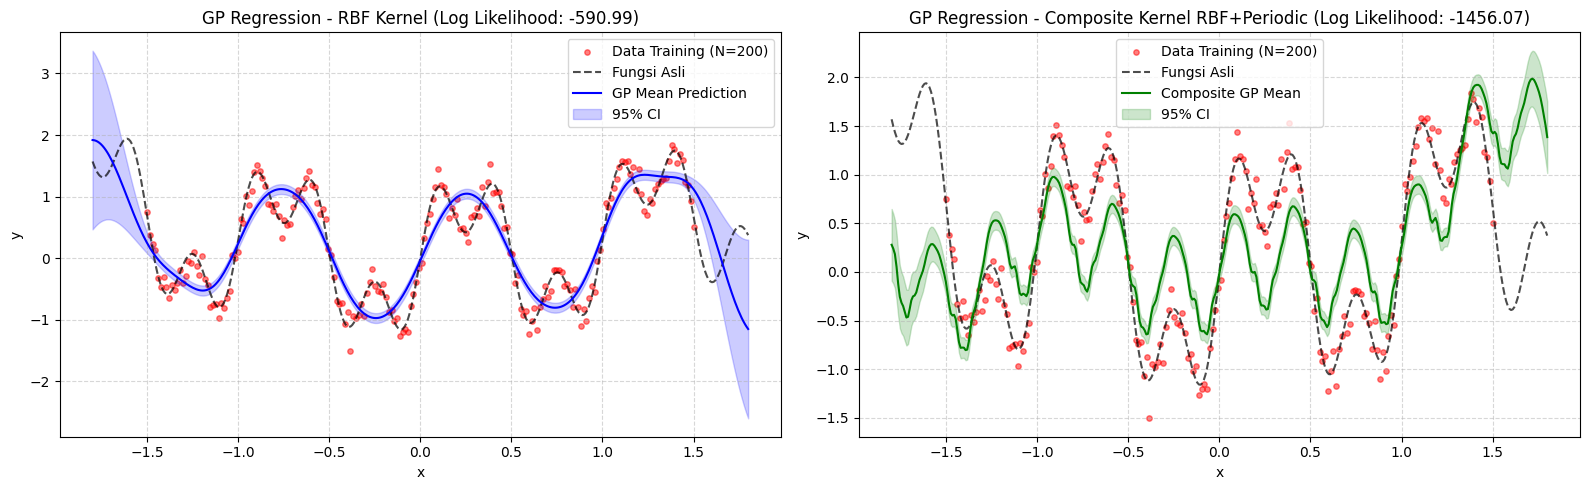

In [6]:
# 1. Model GP dengan RBF Kernel Standar
rbf_kernel = RBFKernel(length_scale=0.25, variance=1.0)
gp_rbf = GaussianProcessRegressor(kernel=rbf_kernel, noise_std=0.15)
gp_rbf.fit(X_train, y_train)
mu_rbf, std_rbf = gp_rbf.predict(X_test, return_std=True)

# 2. Model GP dengan Composite Kernel (RBF + Periodic)
comp_kernel = RBFKernel(length_scale=0.8, variance=0.8) + PeriodicKernel(length_scale=0.5, period=0.33, variance=0.5)
gp_comp = GaussianProcessRegressor(kernel=comp_kernel, noise_std=0.15)
gp_comp.fit(X_train, y_train)
mu_comp, std_comp = gp_comp.predict(X_test, return_std=True)

# Plotting Perbandingan
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot RBF Kernel
axes[0].scatter(X_train, y_train, c='red', s=15, alpha=0.5, label='Data Training (N=200)')
axes[0].plot(X_test, y_test_true, 'k--', label='Fungsi Asli', alpha=0.7)
axes[0].plot(X_test, mu_rbf, 'b-', label='GP Mean Prediction')
axes[0].fill_between(X_test.ravel(), mu_rbf - 1.96 * std_rbf, mu_rbf + 1.96 * std_rbf, color='blue', alpha=0.2, label='95% CI')
axes[0].set_title(f"GP Regression - RBF Kernel (Log Likelihood: {gp_rbf.log_marginal_likelihood():.2f})")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.5)

# Plot Composite Kernel
axes[1].scatter(X_train, y_train, c='red', s=15, alpha=0.5, label='Data Training (N=200)')
axes[1].plot(X_test, y_test_true, 'k--', label='Fungsi Asli', alpha=0.7)
axes[1].plot(X_test, mu_comp, 'g-', label='Composite GP Mean')
axes[1].fill_between(X_test.ravel(), mu_comp - 1.96 * std_comp, mu_comp + 1.96 * std_comp, color='green', alpha=0.2, label='95% CI')
axes[1].set_title(f"GP Regression - Composite Kernel RBF+Periodic (Log Likelihood: {gp_comp.log_marginal_likelihood():.2f})")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

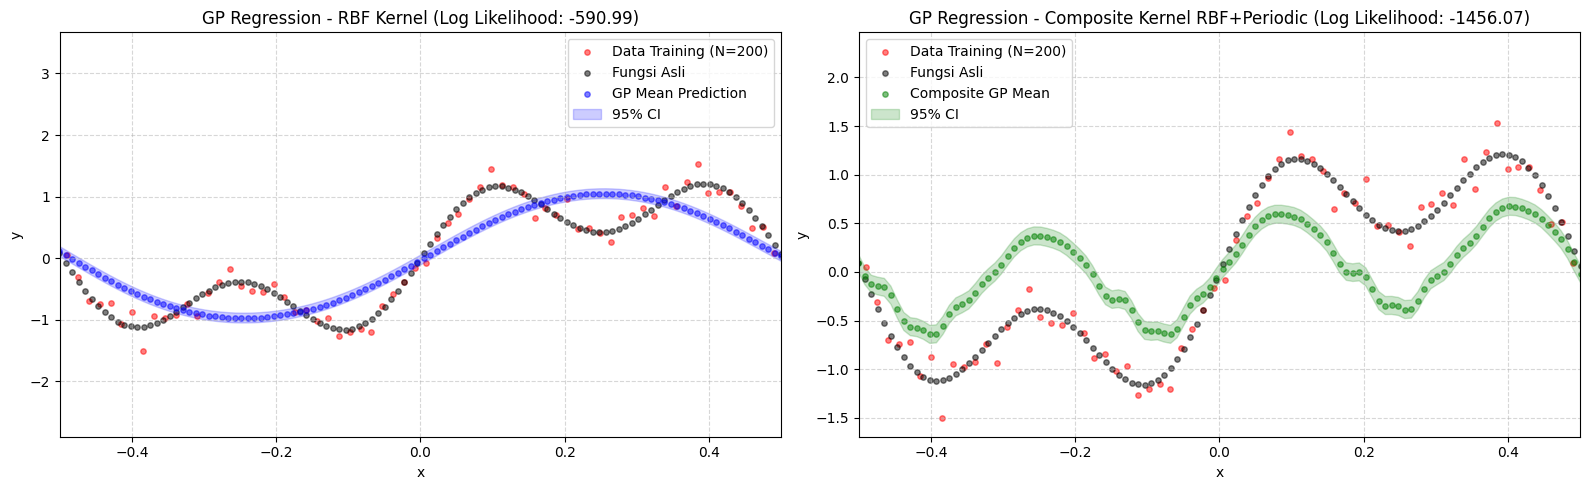

In [7]:
# 1. Model GP dengan RBF Kernel Standar
rbf_kernel = RBFKernel(length_scale=0.25, variance=1.0)
gp_rbf = GaussianProcessRegressor(kernel=rbf_kernel, noise_std=0.15)
gp_rbf.fit(X_train, y_train)
mu_rbf, std_rbf = gp_rbf.predict(X_test, return_std=True)

# 2. Model GP dengan Composite Kernel (RBF + Periodic)
comp_kernel = RBFKernel(length_scale=0.8, variance=0.8) + PeriodicKernel(length_scale=0.5, period=0.33, variance=0.5)
gp_comp = GaussianProcessRegressor(kernel=comp_kernel, noise_std=0.15)
gp_comp.fit(X_train, y_train)
mu_comp, std_comp = gp_comp.predict(X_test, return_std=True)

# Plotting Perbandingan
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot RBF Kernel
axes[0].scatter(X_train, y_train, c='red', s=15, alpha=0.5, label='Data Training (N=200)')
axes[0].scatter(X_test, y_test_true, c='k', s=15, alpha=0.5, label='Fungsi Asli')
axes[0].scatter(X_test, mu_rbf, c='b', s=15, alpha=0.5, label='GP Mean Prediction')
axes[0].fill_between(X_test.ravel(), mu_rbf - 1.96 * std_rbf, mu_rbf + 1.96 * std_rbf, color='blue', alpha=0.2, label='95% CI')
axes[0].set_title(f"GP Regression - RBF Kernel (Log Likelihood: {gp_rbf.log_marginal_likelihood():.2f})")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].set_xlim(-0.5, 0.5)
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.5)

# Plot Composite Kernel
axes[1].scatter(X_train, y_train, c='red', s=15, alpha=0.5, label='Data Training (N=200)')
axes[1].scatter(X_test, y_test_true, c='k', s=15, alpha=0.5, label='Fungsi Asli')
axes[1].scatter(X_test, mu_comp, c='g', s=15, alpha=0.5,label='Composite GP Mean')
axes[1].fill_between(X_test.ravel(), mu_comp - 1.96 * std_comp, mu_comp + 1.96 * std_comp, color='green', alpha=0.2, label='95% CI')
axes[1].set_title(f"GP Regression - Composite Kernel RBF+Periodic (Log Likelihood: {gp_comp.log_marginal_likelihood():.2f})")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_xlim(-0.5, 0.5)
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## 7. Optimasi Hyperparameter & Perbandingan Priori vs Posteriori

Alih-alih menebak hyperparameter kernel secara manual, kita dapat mengoptimalkannya dengan memaksimalkan Log Marginal Likelihood (atau meminimalkan **Negative Log Marginal Likelihood / NLML**):

$$\text{NLML}(\boldsymbol{\theta}) = -\log p(\mathbf{y} \mid \mathbf{X}, \boldsymbol{\theta})$$

Kita menggunakan algoritma optimasi berbasis gradien **L-BFGS-B** via `scipy.optimize.minimize`. Setelah menemukan hyperparameter optimal, kita visualisasikan perbandingan antara **GP Prior** (sebelum observasi) dan **GP Posterior** (setelah melihat data $N=200$). Perhatikan bagaimana pita ketidakpastian (95% CI) pada posterior menguncup di sekitar titik observasi dibanding pita priori yang seragam lebar.

Hyperparameter Optimal RBF Kernel:
- Length-scale (l) : 0.0010
- Variance (sigma_f^2) : 0.7612
- Optimal Log Likelihood: -259.4121


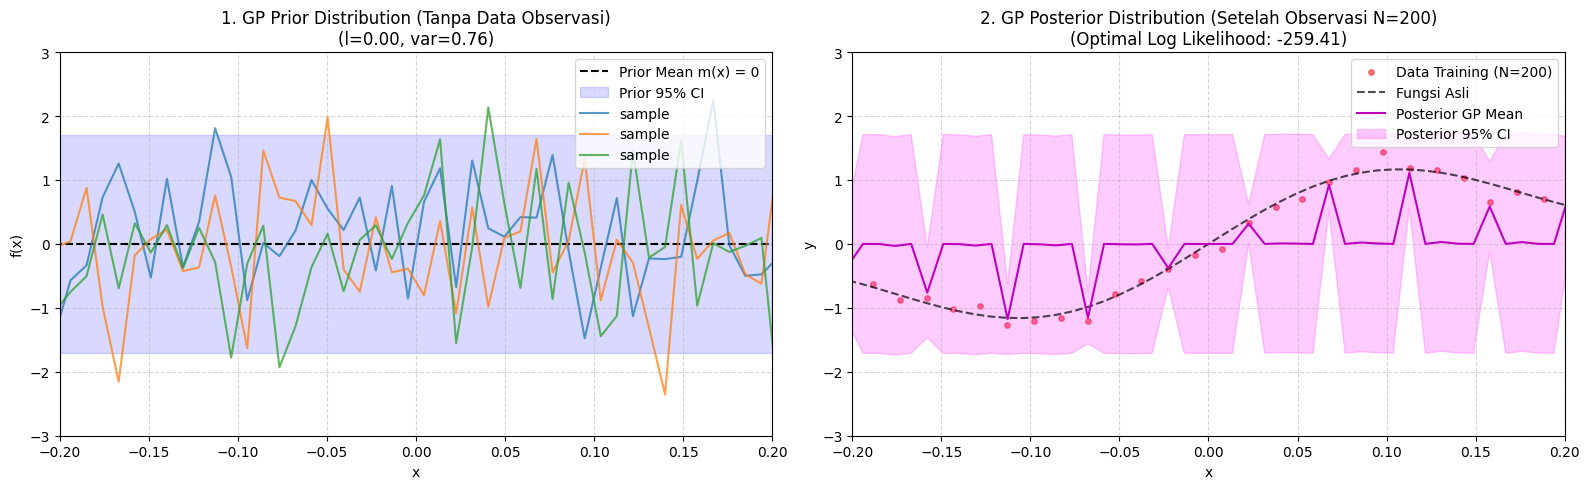

In [8]:
def nlm_objective(params):
    length_scale, variance = params
    if length_scale <= 0 or variance <= 0:
        return 1e10
    
    kernel = RBFKernel(length_scale=length_scale, variance=variance)
    gp = GaussianProcessRegressor(kernel=kernel, noise_std=0.15)
    gp.fit(X_train, y_train)
    return -gp.log_marginal_likelihood()

# Optimasi hyperparameter RBF Kernel
res = minimize(nlm_objective, x0=[0.5, 1.0], bounds=[(1e-3, 5.0), (1e-3, 10.0)], method='L-BFGS-B')
opt_l, opt_var = res.x

print(f"Hyperparameter Optimal RBF Kernel:")
print(f"- Length-scale (l) : {opt_l:.4f}")
print(f"- Variance (sigma_f^2) : {opt_var:.4f}")
print(f"- Optimal Log Likelihood: {-res.fun:.4f}")

# Fit model GP dengan hyperparameter optimal
rbf_opt = RBFKernel(length_scale=opt_l, variance=opt_var)
gp_opt = GaussianProcessRegressor(kernel=rbf_opt, noise_std=0.15)
gp_opt.fit(X_train, y_train)
mu_opt, std_opt = gp_opt.predict(X_test, return_std=True)

# Hitung Distribusi Prior (Sebelum Observasi)
K_ss = rbf_opt(X_test, X_test) + 1e-8 * np.eye(len(X_test))
std_prior = np.sqrt(np.diag(K_ss))
L_ss = np.linalg.cholesky(K_ss)
np.random.seed(42)
u_prior = np.random.normal(0, 1, size=(len(X_test), 3))
prior_samples = np.dot(L_ss, u_prior)

# Plotting Perbandingan GP Prior vs GP Posterior
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Subplot 1: GP Prior (Sebelum Observasi Data)
axes[0].plot(X_test, np.zeros_like(X_test), 'k--', label='Prior Mean m(x) = 0')
axes[0].fill_between(X_test.ravel(), -1.96 * std_prior, 1.96 * std_prior, color='blue', alpha=0.15, label='Prior 95% CI')
axes[0].plot(X_test, prior_samples, alpha=0.75, linestyle='-', label="sample")
axes[0].set_title(f"1. GP Prior Distribution (Tanpa Data Observasi)\n(l={opt_l:.2f}, var={opt_var:.2f})")
axes[0].set_xlabel("x")
axes[0].set_ylabel("f(x)")
axes[0].set_ylim(-3, 3)
axes[0].set_xlim(-0.2, 0.2)
axes[0].legend(loc='upper right')
axes[0].grid(True, linestyle="--", alpha=0.5)

# Subplot 2: GP Posterior (Setelah Observasi Data N=200)
axes[1].scatter(X_train, y_train, c='red', s=15, alpha=0.5, label='Data Training (N=200)')
axes[1].plot(X_test, y_test_true, 'k--', label='Fungsi Asli', alpha=0.7)
axes[1].plot(X_test, mu_opt, 'm-', label='Posterior GP Mean')
axes[1].fill_between(X_test.ravel(), mu_opt - 1.96 * std_opt, mu_opt + 1.96 * std_opt, color='magenta', alpha=0.2, label='Posterior 95% CI')
axes[1].set_title(f"2. GP Posterior Distribution (Setelah Observasi N=200)\n(Optimal Log Likelihood: {-res.fun:.2f})")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].set_ylim(-3, 3)
axes[1].set_xlim(-0.2, 0.2)
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

## 8. Ringkasan & Kesimpulan

1. **Gaussian Process** adalah pendekatan non-parametrik probabilistik yang tidak hanya memberikan estimasi nilai prediksi (mean), tetapi juga **ketidakpastian (interval kepercayaan)** dari prediksi tersebut.
2. **Dekomposisi Cholesky** merupakan kunci utama implementasi GP *from scratch* untuk menjamin stabilitas numerik dan efisiensi perhitungan invers matriks kovarians $\mathbf{K}_y^{-1}$.
3. **Pemilihan dan Komposisi Kernel** menentukan kemampuan model dalam menangkap struktur data (misal: RBF untuk kehalusan umum, Periodic untuk komponen berulang, dan penambahannya untuk menangkap sinyal kompleks).
4. **Log Marginal Likelihood** memberikan kriteria matematis yang objektif untuk tuning hyperparameter tanpa perlu melatih uji coba silang (*cross-validation*) secara manual.